In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.neural_network import MLPClassifier


In [ ]:
data_path = "../../data/Student_performance_data _.csv"
df = pd.read_csv(data_path)
print(df.columns.tolist())


['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']


In [ ]:
print(df.head())
print(df.shape)
print(df.isnull().sum())
print(df["GradeClass"].value_counts())


   StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       0      0   

   Volunteering       GPA  GradeClass  
0             0  2.929196         2.0  
1             0  3

In [ ]:
target_col = "GradeClass"
drop_cols = ["StudentID"]

X = df.drop(columns=drop_cols + [target_col])
y = df[target_col]

print("X shape:", X.shape)
print("y shape:", y.shape)
print(X.head())


X shape: (2392, 13)
y shape: (2392,)
   Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  Absences  \
0   17       1          0                  2        19.833723         7   
1   18       0          0                  1        15.408756         0   
2   15       0          2                  3         4.210570        26   
3   17       1          0                  3        10.028829        14   
4   17       1          0                  2         4.672495        17   

   Tutoring  ParentalSupport  Extracurricular  Sports  Music  Volunteering  \
0         1                2                0       0      1             0   
1         0                1                0       0      0             0   
2         0                2                0       0      0             0   
3         0                3                1       0      0             0   
4         1                3                0       0      0             0   

        GPA  
0  2.929196  
1  3.042915  
2

In [ ]:
label_enc = LabelEncoder()
y_encoded = label_enc.fit_transform(y)
print("Target classes:", label_enc.classes_)


Target classes: [0. 1. 2. 3. 4.]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (1913, 13)
Test shape: (479, 13)


In [ ]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


Numeric features: ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA']
Categorical features: []


In [ ]:
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("feature_selection", SelectKBest(score_func=f_classif)),
    ("classifier", MLPClassifier(random_state=42, early_stopping=True))
])


In [ ]:
param_grid = {
    "feature_selection__k": [3, 5, 7, "all"],
    "classifier__hidden_layer_sizes": [(64, 32), (128, 64, 32)],
    "classifier__activation": ["relu", "tanh"],
    "classifier__alpha": [0.0001, 0.001],
    "classifier__learning_rate_init": [0.001, 0.01]
}


In [ ]:
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=2
)
grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)
print("\nBest CV F1 Macro:", grid_search.best_score_)


Fitting 5 folds for each of 64 candidates, totalling 320 fits


In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="macro")
recall = recall_score(y_test, y_pred, average="macro")
f1 = f1_score(y_test, y_pred, average="macro")

print("Test Metrics - Neural Network (MLP):")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro): {recall:.4f}")
print(f"F1-score (macro): {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[str(c) for c in label_enc.classes_]))


Test Metrics - Neural Network (MLP):
Accuracy: 0.9061
Precision (macro): 0.9087
Recall (macro): 0.8140
F1-score (macro): 0.8422

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.48      0.65        21
         1.0       0.88      0.81      0.85        54
         2.0       0.87      0.95      0.91        78
         3.0       0.86      0.87      0.86        83
         4.0       0.94      0.96      0.95       243

    accuracy                           0.91       479
   macro avg       0.91      0.81      0.84       479
weighted avg       0.91      0.91      0.90       479



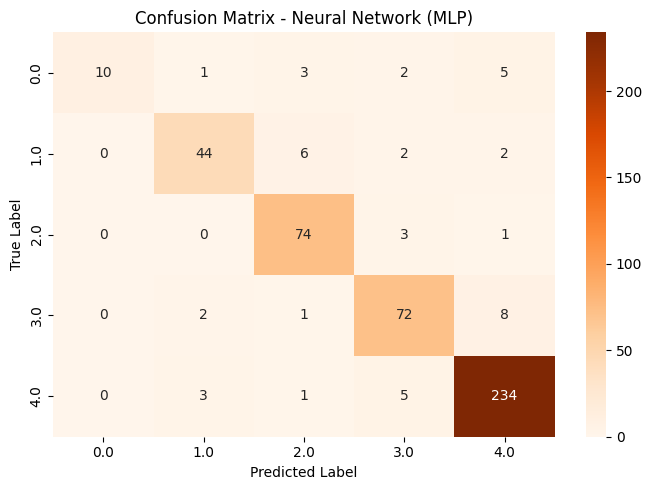

In [ ]:
cm = confusion_matrix(y_test, y_pred)
os.makedirs("../../visualizations", exist_ok=True)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges",
            xticklabels=label_enc.classes_, yticklabels=label_enc.classes_)
plt.title("Confusion Matrix - Neural Network (MLP)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("../../visualizations/neural_network_confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
results_df = pd.DataFrame({
    "Model": ["Neural Network (MLP)"],
    "Best_Params": [str(grid_search.best_params_)],
    "CV_F1_Macro": [grid_search.best_score_],
    "Test_Accuracy": [accuracy],
    "Test_Precision_Macro": [precision],
    "Test_Recall_Macro": [recall],
    "Test_F1_Macro": [f1]
})
os.makedirs("../../results", exist_ok=True)
results_df.to_csv("../../results/neural_network_results.csv", index=False)
print("Results saved to ../../results/neural_network_results.csv")


Results saved to ../../results/neural_network_results.csv
